# Gold/USD — Exploratory Data Analysis

**Ironhack Final Project 2 — ML on Cloud**

This notebook answers one question before any model is built: *is there anything
here that can be predicted, and if so, what?*

The findings drive concrete decisions recorded in `docs/decisions.md`:

| Finding | Decision |
|---|---|
| The price level is non-stationary, returns are not | ADR-10: model returns, not price |
| Returns show almost no autocorrelation | Expect the naive baseline to be hard to beat |
| Absolute returns show strong autocorrelation | A second target worth modelling: volatility |
| 2026 is a different volatility regime | Drift monitoring reference must be model-bound (ADR-12) |


In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Run from the repository root so `src` is importable.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")


## 1. Loading the data

Five instruments, ten years of daily data. Gold is the target; the other four are
explanatory markets chosen for economic reasons rather than by fishing for
correlations:

| Series | Why it is here |
|---|---|
| **Gold futures** (`GC=F`) | the target instrument |
| **Dollar index** (`DX-Y.NYB`) | gold is priced in USD — a stronger dollar pushes the price down |
| **Crude oil** (`CL=F`) | shared inflation driver |
| **S&P 500** (`^GSPC`) | risk appetite; gold is the counterweight |
| **VIX** (`^VIX`) | fear gauge; gold tends to rise on panic |

Every download is validated before use — minimum row count, required columns,
plausible value ranges, and a check for stale feeds. `yfinance` is an unofficial
scraper without an SLA, so a broken download has to fail loudly here rather than
quietly poison the training data.


In [2]:
from src.data.fetch import fetch_all, TICKERS

frames = fetch_all(period="10y")

overview = pd.DataFrame({
    name: {
        "ticker": TICKERS[name],
        "rows": len(df),
        "from": df.index[0].date(),
        "to": df.index[-1].date(),
    }
    for name, df in frames.items()
}).T
overview


,ticker,rows,from,to
gold,GC=F,2514,2016-09-26,2026-09-25
dxy,DX-Y.NYB,2513,2016-09-26,2026-09-25
oil,CL=F,2514,2016-09-26,2026-09-25
sp500,^GSPC,2512,2016-09-26,2026-09-24
vix,^VIX,2515,2016-09-26,2026-09-25


## 2. Data quality

Four markets, four different trading calendars. Gold futures trade nearly around
the clock, equities have fixed sessions, and public holidays differ between them.
How those gaps are handled decides whether the dataset leaks future information.

**The rule applied throughout: forward-fill only, never backfill.** Forward-filling
carries a known past value forward. Backfilling would move a future value into the
past, which is leakage and would invalidate every result that follows.


In [3]:
from src.features.pipeline import align_panel

panel = align_panel(frames)

quality = pd.DataFrame({
    "missing_before_align": {n: frames[n]["close"].isna().sum() for n in frames},
    "rows_raw": {n: len(frames[n]) for n in frames},
})
quality["rows_on_gold_calendar"] = len(panel)
quality["missing_after_ffill"] = [panel[f"{n}_close"].isna().sum() if f"{n}_close" in panel else 0
                                  for n in quality.index]
quality


,missing_before_align,rows_raw,rows_on_gold_calendar,missing_after_ffill
gold,0,2514,2514,0
dxy,0,2513,2514,0
oil,0,2514,2514,0
sp500,0,2512,2514,0
vix,0,2515,2514,0


In [4]:
# How far apart are the calendars? Days present for gold but not for the others.
gold_days = set(frames["gold"].index)
for name in ["dxy", "oil", "sp500", "vix"]:
    missing = len(gold_days - set(frames[name].index))
    print(f"{name:6s}: {missing:4d} gold trading days without an own observation "
          f"({missing / len(gold_days):.1%})")


dxy   :    3 gold trading days without an own observation (0.1%)
oil   :    1 gold trading days without an own observation (0.0%)
sp500 :    5 gold trading days without an own observation (0.2%)
vix   :    4 gold trading days without an own observation (0.2%)


## 3. The price level

The first look, and already the first warning sign.


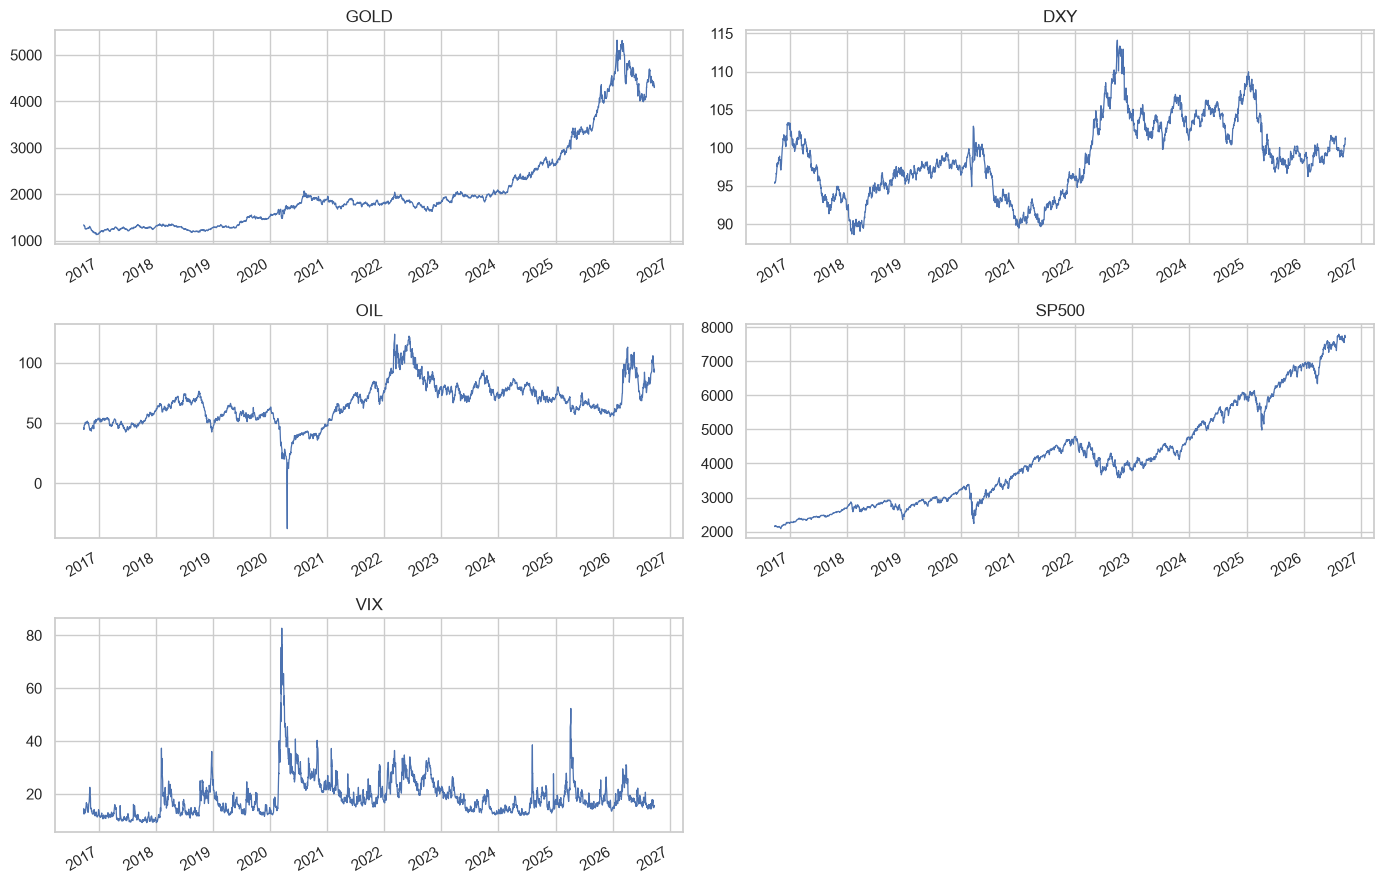

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for ax, (name, col) in zip(axes.flat, [(n, f"{n}_close") for n in
                                        ["gold", "dxy", "oil", "sp500", "vix"]]):
    panel[col].plot(ax=ax, linewidth=0.9)
    ax.set_title(name.upper())
    ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


In [6]:
# Gold by year - the recent move is not subtle.
gold_year = panel["gold_close"].groupby(panel.index.year).agg(["min", "mean", "max"])
gold_year["change_%"] = gold_year["mean"].pct_change() * 100
gold_year


,min,mean,max,change_%
date,,,,
2016,"1,127.80005","1,224.21365","1,339.69995",NaN
2017,"1,160.40002","1,257.69721","1,346.00000",2.73511
2018,"1,176.19995","1,267.59960","1,362.40002",0.78734
2019,"1,269.30005","1,392.72222","1,550.30005",9.87083
2020,"1,477.30005","1,776.81423","2,069.39990",27.57851
2021,"1,678.00000","1,798.90754","1,954.40002",1.24342
2022,"1,630.90002","1,805.19163","2,043.30005",0.34933
2023,"1,817.09998","1,954.51952","2,093.10010",8.27214
2024,"2,004.30005","2,404.71309","2,800.80005",23.03346


Gold roughly doubled between 2024 and 2026. A model trained across the whole
decade therefore learns mostly from a market that no longer exists — a point we
return to in section 8.


## 4. Stationarity

A stationary series has a constant mean and variance over time. Most time-series
methods assume it, and the assumption is not cosmetic: fitting a model to a
non-stationary series produces impressive-looking metrics that mean nothing.

Two tests with **opposite null hypotheses** are used, because agreement between
them is far more convincing than either alone:

- **ADF** — null: the series has a unit root (non-stationary). `p < 0.05` → stationary.
- **KPSS** — null: the series is stationary. `p < 0.05` → non-stationary.


In [7]:
price = panel["gold_close"].dropna()
returns = price.pct_change().dropna()
abs_returns = returns.abs()

def stationarity_table(series_map):
    rows = []
    for name, s in series_map.items():
        adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
        kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
        rows.append({
            "series": name,
            "ADF_stat": adf_stat, "ADF_p": adf_p,
            "ADF_verdict": "stationary" if adf_p < 0.05 else "NON-stationary",
            "KPSS_stat": kpss_stat, "KPSS_p": kpss_p,
            "KPSS_verdict": "NON-stationary" if kpss_p < 0.05 else "stationary",
        })
    return pd.DataFrame(rows).set_index("series")

stationarity_table({
    "gold price level": price,
    "gold returns": returns,
    "absolute returns": abs_returns,
})


/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_12622/3204455238.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_12622/3204455238.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_12622/3204455238.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


,ADF_stat,ADF_p,ADF_verdict,KPSS_stat,KPSS_p,KPSS_verdict
series,,,,,,
gold price level,1.18961,0.99591,NON-stationary,5.94040,0.01000,NON-stationary
gold returns,-21.17980,0.00000,stationary,0.31734,0.10000,stationary
absolute returns,-7.94848,0.00000,stationary,2.77919,0.01000,NON-stationary


**Result.**

| Series | ADF | KPSS | Verdict |
|---|---|---|---|
| Price level | non-stationary | non-stationary | ❌ both agree |
| Returns | stationary | stationary | ✅ both agree |
| Absolute returns | stationary | non-stationary | ⚠️ tests disagree |

The price level is clearly non-stationary — **this is the statistical evidence
behind ADR-10**. Differencing once (i.e. taking returns) makes it stationary, which
is exactly the "I" in ARIMA.

The disagreement on absolute returns is itself a finding rather than a problem: it
points to *long memory* in volatility — stationary, but with very slowly decaying
dependence. A well-documented property of financial series, and the reason GARCH
models exist.


## 5. Distribution of returns

Before asking whether returns can be predicted, it is worth knowing what they look
like.


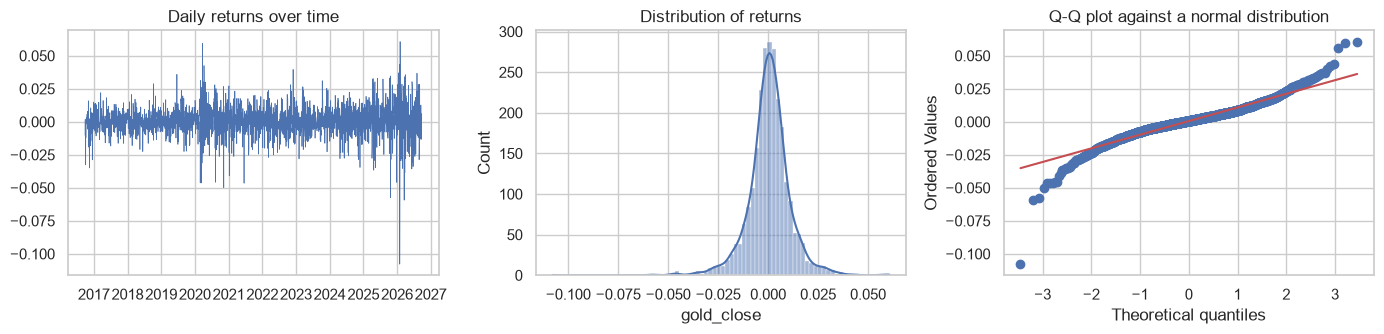

mean       : +0.000524   (+13.20% annualised)
std        : 0.010681    (16.96% annualised)
skew       : -0.5682
kurtosis   : +7.5597   (0 = normal; positive = fat tails)
share up   : 0.5360


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(returns.index, returns.values, linewidth=0.5)
axes[0].set_title("Daily returns over time")

sns.histplot(returns, bins=80, kde=True, ax=axes[1])
axes[1].set_title("Distribution of returns")

from scipy import stats
stats.probplot(returns, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot against a normal distribution")

plt.tight_layout()
plt.show()

print(f"mean       : {returns.mean():+.6f}   ({returns.mean() * 252:+.2%} annualised)")
print(f"std        : {returns.std():.6f}    ({returns.std() * np.sqrt(252):.2%} annualised)")
print(f"skew       : {returns.skew():+.4f}")
print(f"kurtosis   : {returns.kurtosis():+.4f}   (0 = normal; positive = fat tails)")
print(f"share up   : {(returns > 0).mean():.4f}")


The Q-Q plot bends away from the line at both ends and the excess kurtosis is
clearly positive: **fat tails**. Extreme days occur far more often than a normal
distribution would predict. This matters for risk statements — "two standard
deviations" understates the real danger — and it is one reason RMSE alone is a
poor description of this problem.


## 6. Autocorrelation — is there anything to predict?

This is the decisive section. If returns carry no autocorrelation, then lag
features cannot contain linear signal, and no amount of model tuning will change
that.

The blue band is the 95% interval for white noise: bars inside it are
indistinguishable from randomness.


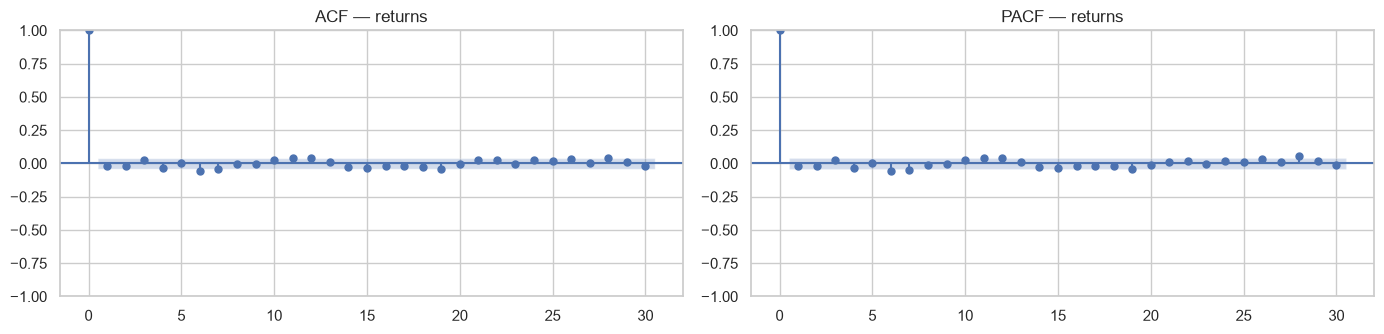

,ACF,PACF,significant
lag,,,
1,-0.02210,-0.02210,-
2,-0.01790,-0.01840,-
3,0.02330,0.02250,-
4,-0.03100,-0.03040,-
5,0.00310,0.00260,-
6,-0.05710,-0.05890,yes
7,-0.04460,-0.04600,yes
8,-0.00370,-0.00910,-
9,-0.00380,-0.00310,-


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_acf(returns, lags=30, ax=axes[0], title="ACF — returns")
plot_pacf(returns, lags=30, ax=axes[1], title="PACF — returns", method="ywm")
plt.tight_layout()
plt.show()

ci = 1.96 / np.sqrt(len(returns))
a, p_ = acf(returns, nlags=10, fft=True), pacf(returns, nlags=10)
pd.DataFrame({
    "ACF": a[1:11].round(4),
    "PACF": p_[1:11].round(4),
    "significant": ["yes" if abs(v) > ci else "-" for v in a[1:11]],
}, index=pd.RangeIndex(1, 11, name="lag"))


In [10]:
lb = acorr_ljungbox(returns, lags=[5, 10, 20], return_df=True)
print(f"95% white-noise band: +/- {ci:.4f}   (n = {len(returns)})\n")
print("Ljung-Box, joint test across lags:")
print(lb.round(6))


95% white-noise band: +/- 0.0391   (n = 2513)

Ljung-Box, joint test across lags:
    lb_stat  lb_pvalue
5   5.84445    0.32165
10 20.73557    0.02302
20 41.03657    0.00368


Only two of the first ten lags cross the threshold — at a 5% significance level,
roughly one in twenty crossings is expected by chance alone, so two out of ten is
barely more than noise. Ljung-Box sits close to the boundary.

**Conclusion: daily gold returns are, for practical purposes, white noise.** This
predicts the modelling outcome before a single model is fitted: the naive baseline
will be hard to beat.


## 7. Volatility clustering — where the signal actually is

The same analysis on *absolute* returns. Dropping the sign discards the direction
and keeps the magnitude: how violently the market moved, regardless of which way.


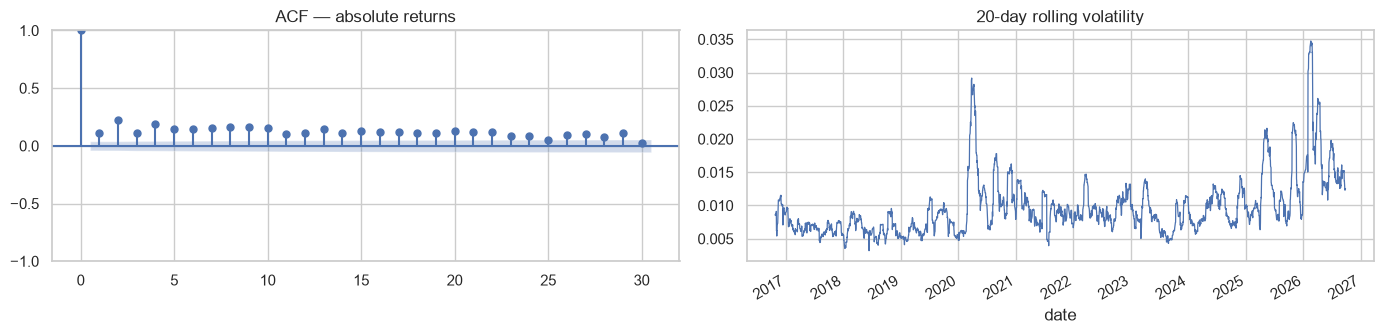

,ACF returns,ACF abs returns,ratio
lag,,,
1,-0.02210,0.10700,4.80000
2,-0.01790,0.22210,12.40000
3,0.02330,0.11540,5.00000
4,-0.03100,0.18670,6.00000
5,0.00310,0.14720,47.50000
6,-0.05710,0.14160,2.50000
7,-0.04460,0.15850,3.60000
8,-0.00370,0.15950,43.10000
9,-0.00380,0.16540,43.50000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_acf(abs_returns, lags=30, ax=axes[0], title="ACF — absolute returns")
panel["gold_close"].pct_change().rolling(20).std().plot(
    ax=axes[1], linewidth=0.9, title="20-day rolling volatility")
plt.tight_layout()
plt.show()

aa = acf(abs_returns, nlags=10, fft=True)
comparison = pd.DataFrame({
    "ACF returns": a[1:11].round(4),
    "ACF abs returns": aa[1:11].round(4),
}, index=pd.RangeIndex(1, 11, name="lag"))
comparison["ratio"] = (comparison["ACF abs returns"].abs()
                       / comparison["ACF returns"].abs()).round(1)
comparison


In [12]:
lb_ret = acorr_ljungbox(returns, lags=[10], return_df=True)
lb_abs = acorr_ljungbox(abs_returns, lags=[10], return_df=True)

print("Ljung-Box across lags 1-10")
print(f"  returns          stat = {lb_ret['lb_stat'].iloc[0]:8.2f}   p = {lb_ret['lb_pvalue'].iloc[0]:.6f}")
print(f"  absolute returns stat = {lb_abs['lb_stat'].iloc[0]:8.2f}   p = {lb_abs['lb_pvalue'].iloc[0]:.6f}")
print(f"\n  factor between the two: {lb_abs['lb_stat'].iloc[0] / lb_ret['lb_stat'].iloc[0]:.0f}x")


Ljung-Box across lags 1-10
  returns          stat =    20.74   p = 0.023015
  absolute returns stat =   638.83   p = 0.000000

  factor between the two: 31x


Every one of the first ten lags is clearly significant, with no decay, and the
rolling-volatility chart shows the mechanism directly: calm periods follow calm
periods, turbulent ones follow turbulent ones.

The Ljung-Box statistic is roughly **thirty times higher** than for returns.

**This is the central finding of the analysis.** Direction is unpredictable,
magnitude is not — which is why the project models both and reports honestly which
of the two holds up.


## 8. External markets

Do the explanatory series carry information about gold, and do they carry it
*before* gold moves? The second question is the one that matters: a correlation
with today's move is not a forecast.


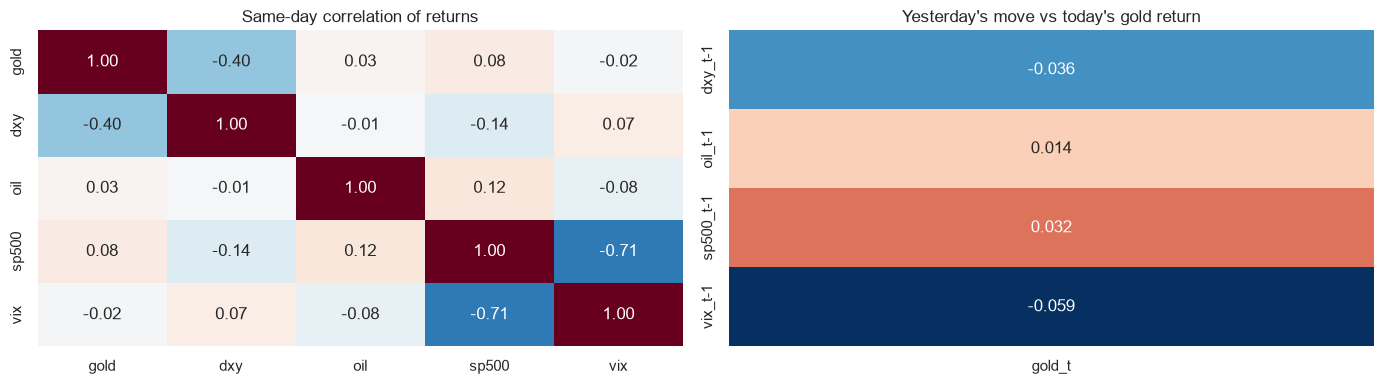

In [13]:
ret_panel = pd.DataFrame({
    name: panel[f"{name}_close"].pct_change()
    for name in ["gold", "dxy", "oil", "sp500", "vix"]
    if f"{name}_close" in panel
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ret_panel.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], cbar=False)
axes[0].set_title("Same-day correlation of returns")

# Lead-lag: does yesterday's move in X relate to today's move in gold?
lagged = pd.DataFrame({
    f"{c}_t-1": ret_panel[c].shift(1) for c in ret_panel.columns if c != "gold"
})
lagged["gold_t"] = ret_panel["gold"]
sns.heatmap(lagged.corr()[["gold_t"]].drop("gold_t"), annot=True, fmt=".3f",
            cmap="RdBu_r", center=0, ax=axes[1], cbar=False)
axes[1].set_title("Yesterday's move vs today's gold return")

plt.tight_layout()
plt.show()


The same-day correlations behave exactly as economic theory predicts — gold moves
against the dollar, and with risk aversion.

**But the lagged correlations are near zero.** Yesterday's dollar move says almost
nothing about today's gold return. That is the same message as the autocorrelation
analysis, arriving from a different direction: the information is already in the
price by the time we could act on it.

The external series are kept regardless, because they contribute to the
*volatility* model — where signal does exist.


## 9. Regime change — the drift finding

The last six months are held out and never used for model selection. Before
trusting that holdout, it is worth checking whether it even resembles the training
period.


In [14]:
from src.features.pipeline import feature_columns, make_training_frame
from src.monitoring.drift import compare

frame = make_training_frame(frames)
cols = feature_columns(frame)
train_frame, holdout_frame = frame.iloc[:-126], frame.iloc[-126:]

drift = compare(train_frame, holdout_frame, cols)
drift.head(12)


,feature,psi,verdict,ks_stat,ks_p,ks_significant
0,gold_vol20,9.58290,significant,0.83750,0.00000,True
1,gold_vol10,6.93720,significant,0.68900,0.00000,True
2,gold_range,6.67550,significant,0.60850,0.00000,True
3,oil_vol10,5.64380,significant,0.59300,0.00000,True
4,month,5.38800,significant,0.26150,0.00000,True
5,gold_vol5,3.28430,significant,0.50650,0.00000,True
6,sp500_vol10,2.60420,significant,0.19530,0.00020,True
7,gold_ret_mean20,1.01350,significant,0.35710,0.00000,True
8,dxy_vol10,0.92700,significant,0.38770,0.00000,True
9,oil_ret_mean5,0.87130,significant,0.25130,0.00000,True


In [15]:
n, m = len(train_frame), len(holdout_frame)
d_crit = 1.36 * np.sqrt((n + m) / (n * m))

print(f"Reference : {train_frame.index[0].date()} to {train_frame.index[-1].date()}  ({n} rows)")
print(f"Holdout   : {holdout_frame.index[0].date()} to {holdout_frame.index[-1].date()}  ({m} rows)")
print(f"\nKS critical value at alpha = 0.05: D = {d_crit:.4f}")
print(f"Features above it: {(drift['ks_stat'] > d_crit).sum()} of {len(drift)}")
print(f"\nPSI verdicts:\n{drift['verdict'].value_counts().to_string()}")


Reference : 2016-10-25 to 2026-03-25  (2367 rows)
Holdout   : 2026-03-26 to 2026-09-24  (126 rows)

KS critical value at alpha = 0.05: D = 0.1243
Features above it: 21 of 29

PSI verdicts:
verdict
significant    21
stable          6
moderate        2


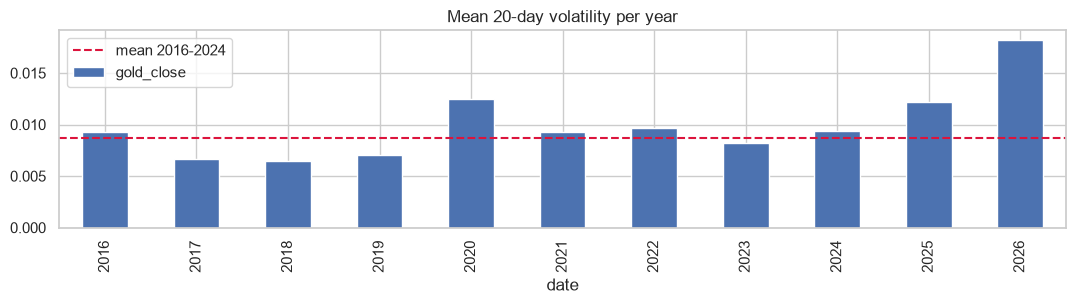

date
2016   0.00928
2017   0.00662
2018   0.00650
2019   0.00709
2020   0.01252
2021   0.00926
2022   0.00965
2023   0.00817
2024   0.00941
2025   0.01218
2026   0.01822
Name: gold_close, dtype: float64

In [16]:
vol_by_year = panel["gold_close"].pct_change().rolling(20).std().groupby(panel.index.year).mean()
ax = vol_by_year.plot(kind="bar", figsize=(11, 3.2),
                      title="Mean 20-day volatility per year")
ax.axhline(vol_by_year.iloc[:-2].mean(), color="crimson", linestyle="--",
           label="mean 2016-2024")
ax.legend()
plt.tight_layout()
plt.show()
vol_by_year.round(5)


**21 of 29 features differ significantly** between the training period and the
holdout, by both KS and PSI. The shift is concentrated almost entirely in the
volatility features — 2026 runs at roughly twice the volatility of the 2016–2024
average.

Three consequences:

1. **The drift monitoring works.** This is a real detection on real data, not a
   synthetic test.
2. **Ten years of history is questionable as a training window.** Most of it
   describes a market that no longer exists.
3. **The holdout is not representative of the training period.** Cross-validation
   results do not transfer to it unchecked, and the holdout result has to be
   reported with that caveat rather than quoted bare.

This is also the concrete reason behind ADR-12: the drift reference belongs to the
model in production and is only rewritten when a new model is promoted. Updating it
on every training run would silently reset the measurement — and a dashboard that
stays green because the measurement broke looks exactly like a healthy one.


## 10. What this analysis decided

| Finding | Evidence | Consequence |
|---|---|---|
| Price level is non-stationary | ADF p = 0.996, KPSS p = 0.01 | Model returns, not prices (ADR-10) |
| Returns are stationary | ADF p < 0.0001, KPSS p = 0.10 | No further differencing needed |
| Returns ≈ white noise | 2 of 10 lags significant, Ljung-Box p = 0.023 | Expect the naive baseline to win; report honestly |
| Volatility clusters strongly | all 10 lags significant, Ljung-Box 30× higher | Second target worth modelling |
| Fat tails, negative skew | excess kurtosis 7.6, skew −0.57 | RMSE alone understates tail risk; downside moves are the larger ones |
| Lagged external correlations ≈ 0 | see section 8 | Keep them for volatility, not for direction |
| 2026 is a different regime | 21 of 29 features drift significantly | Model-bound drift reference (ADR-12); test shorter training windows |

**The honest summary:** the direction of tomorrow's gold price cannot be predicted
from this data — and that conclusion is reached independently by classical time
series analysis and by machine learning. The magnitude of tomorrow's move can be,
modestly. The project reports both.
